# Wind, weather and three seasons of Antarctic recordings

This notebook joins the acoustic analysis of the field corpus to the Frei
station's weather record, and asks three questions:

1. **Does the acoustic wind signal actually track measured wind?** If it does
   not, nothing below means anything.
2. **How does each site respond to wind?** Which places are exposed, which are
   sheltered, and from which direction.
3. **Are we getting better at this?** Comparing seasons *at matched wind
   strength*, so the answer is about deployment rather than about the weather.

Three corrections are applied before any comparison. Each is a way to get a
confident wrong answer if skipped:

| Problem | Why it matters | Handled by |
| --- | --- | --- |
| Recorder gain varies by season *and within* season | A 6 dB gain step looks exactly like a 6 dB noisier soundscape | `report.apply_gain_correction` |
| Filenames are UTC, the station logs UTC-3 | A 3 h error is 18 weather bins | `meteo.load_meteo` + `verify_time_alignment` |
| Seasons met different weather | A windier season yields more windy files regardless of skill | `report.standardize_by_wind` |

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from soundsanity.meteo import (
    WIND_SCALE_BREAK,
    join_meteo,
    load_meteo,
    verify_time_alignment,
)
from soundsanity.report import (
    add_wind_percentile_bands,
    apply_gain_correction,
    deployment_quality,
    direction_response,
    standardize_by_wind,
    wind_response,
    wind_weights,
)

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
ANALYSIS = ROOT / "data" / "analysis"
INVENTORY = ROOT / "data" / "inventory.parquet"
METEO = ROOT / "meteo-data" / "Meteo_2022-2025.xlsx"

plt.rcParams.update({"figure.figsize": (11, 4.5), "axes.grid": True, "grid.alpha": 0.3})

## 1. Load the corpus

Analysis shards, joined to the deployment inventory and then to weather.

In [2]:
shards = sorted(ANALYSIS.glob("part-*.parquet"))
analysis = pd.concat((pd.read_parquet(s) for s in shards), ignore_index=True)
inventory = pd.read_parquet(INVENTORY)

corpus = analysis.merge(
    inventory.drop(columns=["file_name"]), on="path", how="left", suffixes=("", "_inv")
)
meteo = load_meteo(METEO)
joined = join_meteo(corpus.dropna(subset=["timestamp_utc"]), meteo)
joined = apply_gain_correction(joined)

print(f"{len(analysis):,} recordings analyzed")
print(f"{joined['wind_knots'].notna().sum():,} matched to a weather reading")
print(f"seasons: {sorted(joined['season'].dropna().unique())}")
joined.groupby(["season", "site", "medium"], observed=True).size().rename("files").to_frame()

26,050 recordings analyzed
24,105 matched to a weather reading
seasons: ['2022-23', '2023-24', '2024-25']


files
season  site            medium           
2022-23 Frei            air          2114
        Punta Nebles    air          2230
        Tanques Rusos   air          2114
2023-24 Ardley          air          1218
        BCAA1           air          1281
        BCAA2           air          1220
        Colonia Adelia  air          1229
        Colonia Papua   air          1225
        Drake           air          1382
        Frei            air          1202
        Halfthree Point air          1377
        Punta Eulogia   air          1283
        Punta Nebles    air          1244
        Tanques Rusos   air          1324
2024-25 Ardley          underwater   1532
        Colonia Adelia  air          1272
        Colonia Papua   air          1272
        Tanques Rusos   underwater   1531

### The corpus is not a balanced design

Sites come and go between seasons, and the 2024-25 season added hydrophones.
Underwater recordings are held out of the wind analysis entirely: wind reaches a
submerged hydrophone through a completely different path, so mixing them in
would compare two different physical phenomena.

In [3]:
coverage = (
    joined.pivot_table(index="site", columns="season", values="path",
                       aggfunc="count", observed=True)
    .fillna(0).astype(int)
)
display(coverage)

air = joined[joined["medium"] == "air"].copy()
print(f"airborne recordings: {len(air):,}  (held out: {len(joined) - len(air):,} underwater)")
print("\nsites present in every season:",
      sorted(set.intersection(*(set(g["site"]) for _, g in air.groupby("season")))) or "none")

season,2022-23,2023-24,2024-25
site,,,
Ardley,0,1218,1532
BCAA1,0,1281,0
BCAA2,0,1220,0
Colonia Adelia,0,1229,1272
Colonia Papua,0,1225,1272
Drake,0,1382,0
Frei,2114,1202,0
Halfthree Point,0,1377,0
Punta Eulogia,0,1283,0


airborne recordings: 22,987  (held out: 3,063 underwater)

sites present in every season: none


### Gain is not constant

This is the single most important thing to know before reading any level in
this notebook. If gain moved between the seasons being compared, then an
uncorrected dB difference is partly — possibly entirely — the gain knob.

In [4]:
gain_mix = pd.crosstab(air["season"], air["gain"], normalize="index").round(3)
display(gain_mix)
print("nominal offsets applied (dB, relative to 'medium'):")
display(air.groupby("season", observed=True)["gain_offset_db"].mean().round(2).to_frame("mean offset"))

gain,medium,medium-high
season,,
2022-23,0.271,0.729
2023-24,0.000,1.000
2024-25,0.000,1.000


nominal offsets applied (dB, relative to 'medium'):


,mean offset
season,
2022-23,4.37
2023-24,6.00
2024-25,6.00


## 2. The station changed how it measures wind
Before anything is compared across seasons, this has to be established, because
it invalidates the most natural way of doing it.
The wind column steps up across the 184-day winter gap preceding the 2023-24
season. Mean 11.8 -> 18.3 kt, 95th percentile 20 -> 33 kt. What settles it is
the ceiling: in 32,944 readings before the break not one exceeds 34 knots,
while 2,146 of the 51,968 after it do. Fourteen consecutive months without a
single reading above 34 kt is not weather in the South Shetlands.
Temperature, humidity and pressure are unchanged across the same boundary, so
this is the wind instrument or its processing, not a station move. The ratio of
means (1.55) and of 95th percentiles (1.65) both sit where one expects between
a 10-minute *mean* and a 10-minute *maximum* — and the workbook documents
`IntVM` as a maximum.
**Knots either side of this date are different quantities.** 2023-24 and
2024-25 compare directly. 2022-23 cannot be put on the same axis as either.

,n,mean,p50,p95,max
season_year,,,,,
2022,10014,10.8,11.0,19.0,28.0
2023,22930,11.8,12.0,20.0,34.0
2024,26173,18.3,18.0,33.0,65.0
2025,25795,20.4,20.0,36.0,55.0


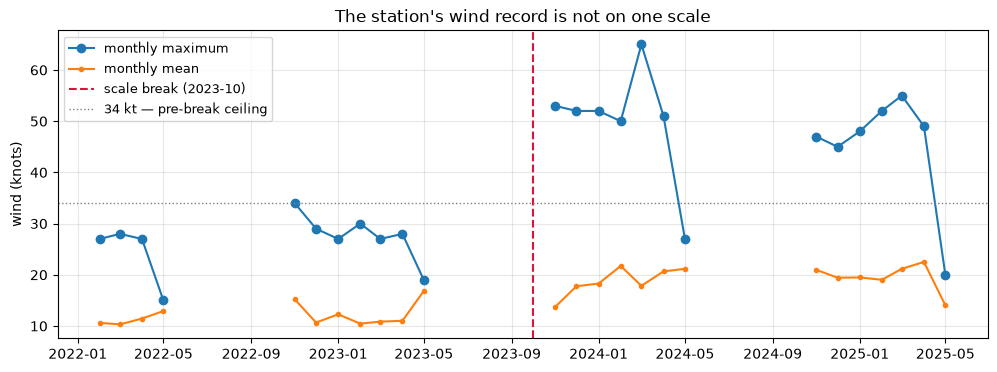

before the break: n=32,944  max=34  above 35 kt: 0
after the break:  n=51,968  max=65  above 35 kt: 2146

ratio of means   post/pre = 1.68
ratio of p95s    post/pre = 1.75
(a 10-minute maximum runs about 1.4-1.7x the 10-minute mean)

controls — unchanged across the same boundary:
  air_temp_c         0.79 ->     0.62
  humidity_pct      87.15 ->    87.08
  pressure_hpa     988.04 ->   989.52


In [5]:
season_wind = (
    meteo.assign(season_year=meteo["timestamp_utc"].dt.year
                 + (meteo["timestamp_utc"].dt.month >= 9).astype(int))
    .groupby("season_year")["wind_knots"]
    .agg(n="count", mean="mean", p50="median",
         p95=lambda s: s.quantile(0.95), max="max")
    .round(1)
)
display(season_wind)
monthly = meteo.set_index("timestamp_utc")["wind_knots"].resample("MS")
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(monthly.max().index, monthly.max().values, marker="o", label="monthly maximum")
ax.plot(monthly.mean().index, monthly.mean().values, marker=".", label="monthly mean")
ax.axvline(WIND_SCALE_BREAK, color="crimson", ls="--", lw=1.5,
           label=f"scale break ({WIND_SCALE_BREAK:%Y-%m})")
ax.axhline(34, color="grey", ls=":", lw=1, label="34 kt — pre-break ceiling")
ax.set(ylabel="wind (knots)", title="The station's wind record is not on one scale")
ax.legend(fontsize=9)
plt.show()
pre = meteo[meteo["timestamp_utc"] < WIND_SCALE_BREAK]["wind_knots"].dropna()
post = meteo[meteo["timestamp_utc"] >= WIND_SCALE_BREAK]["wind_knots"].dropna()
print(f"before the break: n={len(pre):,}  max={pre.max():.0f}  above 35 kt: {(pre > 35).sum()}")
print(f"after the break:  n={len(post):,}  max={post.max():.0f}  above 35 kt: {(post > 35).sum()}")
print(f"\nratio of means   post/pre = {post.mean() / pre.mean():.2f}")
print(f"ratio of p95s    post/pre = {post.quantile(.95) / pre.quantile(.95):.2f}")
print("(a 10-minute maximum runs about 1.4-1.7x the 10-minute mean)")
print("\ncontrols — unchanged across the same boundary:")
for column in ["air_temp_c", "humidity_pct", "pressure_hpa"]:
    a = meteo[meteo["timestamp_utc"] < WIND_SCALE_BREAK][column].mean()
    b = meteo[meteo["timestamp_utc"] >= WIND_SCALE_BREAK][column].mean()
    print(f"  {column:14} {a:8.2f} -> {b:8.2f}")

## 3. Is the clock right?

The station logs local time and the recorders stamp UTC. `load_meteo` shifts by
+3 h; this re-derives the shift from the data. Correlation between the recorded
low-frequency level and measured wind is computed at a range of trial offsets.
If the assumption is right, the peak sits at 0.

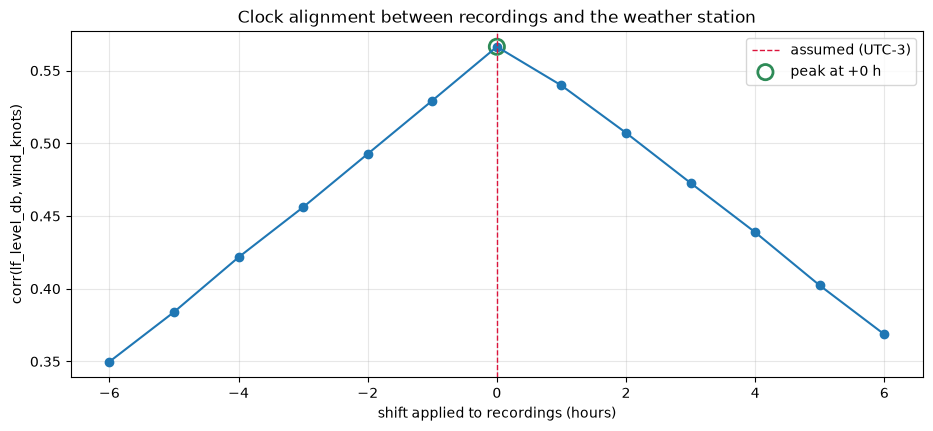

peak at +0 h (r = 0.566)
UTC-3 assumption: confirmed


In [6]:
align = verify_time_alignment(air, meteo, metric="lf_level_db")
best = align.loc[align["correlation"].idxmax()]

fig, ax = plt.subplots()
ax.plot(align["offset_h"], align["correlation"], marker="o")
ax.axvline(0, color="crimson", ls="--", lw=1, label="assumed (UTC-3)")
ax.scatter([best["offset_h"]], [best["correlation"]], s=120, facecolors="none",
           edgecolors="seagreen", lw=2, label=f"peak at {best['offset_h']:+.0f} h")
ax.set(xlabel="shift applied to recordings (hours)",
       ylabel="corr(lf_level_db, wind_knots)",
       title="Clock alignment between recordings and the weather station")
ax.legend()
plt.show()

print(f"peak at {best['offset_h']:+.0f} h (r = {best['correlation']:.3f})")
print("UTC-3 assumption:", "confirmed" if best["offset_h"] == 0 else "WRONG — rerun with the peak offset")

## 4. Does the acoustic signal track measured wind?

The station is kilometres from most sites, so it reports the day's weather
rather than the wind at each microphone. That puts a hard ceiling on the
correlation well below 1.0 — the question is whether a real relationship
survives that.

In [7]:
metrics = ["lf_level_db_gc", "lf_ratio", "wind_index", "rms_db_gc",
           "noise_floor_db_gc", "spectral_tilt", "snr_db"]
rows = []
for metric in metrics:
    pair = air[[metric, "wind_knots"]].dropna()
    rows.append({"metric": metric, "n": len(pair),
                 "pearson_r": pair[metric].corr(pair["wind_knots"]),
                 "spearman_r": pair[metric].corr(pair["wind_knots"], method="spearman")})
pd.DataFrame(rows).sort_values("pearson_r", key=abs, ascending=False).round(3)

,metric,n,pearson_r,spearman_r
3,rms_db_gc,21042,0.571,0.615
2,wind_index,21042,0.566,0.586
5,spectral_tilt,21042,-0.554,-0.587
0,lf_level_db_gc,21042,0.552,0.588
4,noise_floor_db_gc,21042,0.527,0.529
1,lf_ratio,21042,0.299,0.242
6,snr_db,21042,0.038,0.062


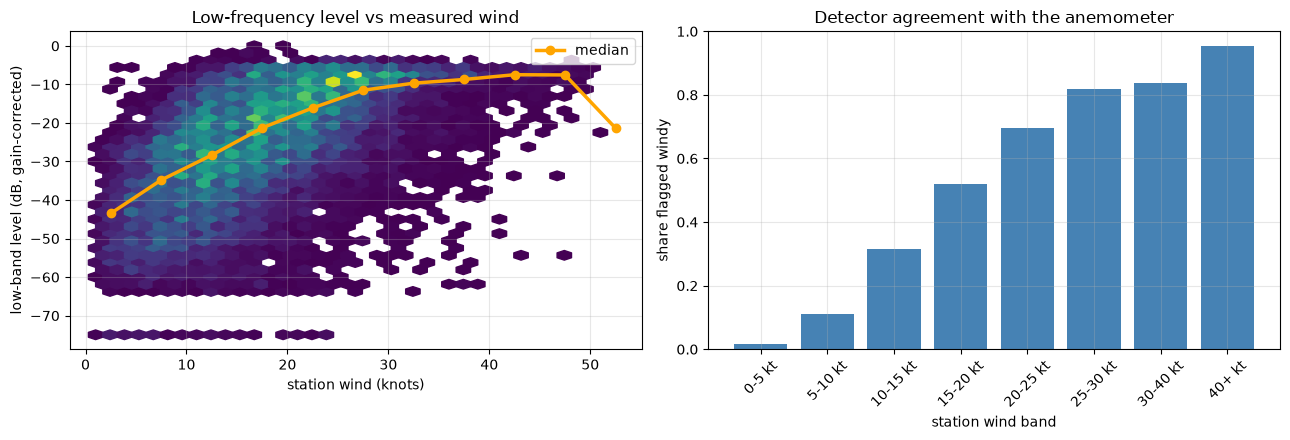

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

sub = air.dropna(subset=["wind_knots", "lf_level_db_gc"])
axes[0].hexbin(sub["wind_knots"], sub["lf_level_db_gc"], gridsize=35,
               cmap="viridis", mincnt=1)
trend = sub.groupby(pd.cut(sub["wind_knots"], np.arange(0, 70, 5)),
                    observed=True)["lf_level_db_gc"].median()
centres = [i.mid for i in trend.index]
axes[0].plot(centres, trend.values, color="orange", lw=2.5, marker="o", label="median")
axes[0].set(xlabel="station wind (knots)", ylabel="low-band level (dB, gain-corrected)",
            title="Low-frequency level vs measured wind")
axes[0].legend()

band_rate = (air.dropna(subset=["wind_band"])
             .groupby("wind_band", observed=True)["is_windy"].agg(["mean", "size"]))
band_rate = band_rate[band_rate["size"] >= 20]
axes[1].bar(band_rate.index.astype(str), band_rate["mean"], color="steelblue")
axes[1].set(xlabel="station wind band", ylabel="share flagged windy",
            title="Detector agreement with the anemometer", ylim=(0, 1))
axes[1].tick_params(axis="x", rotation=45)
plt.tight_layout()
plt.show()

## 5. How does each site respond to wind?

The dose-response curve, per site. A site whose curve sits low and rises slowly
is sheltered; one that starts high and climbs steeply is exposed and is a poor
place for a microphone.

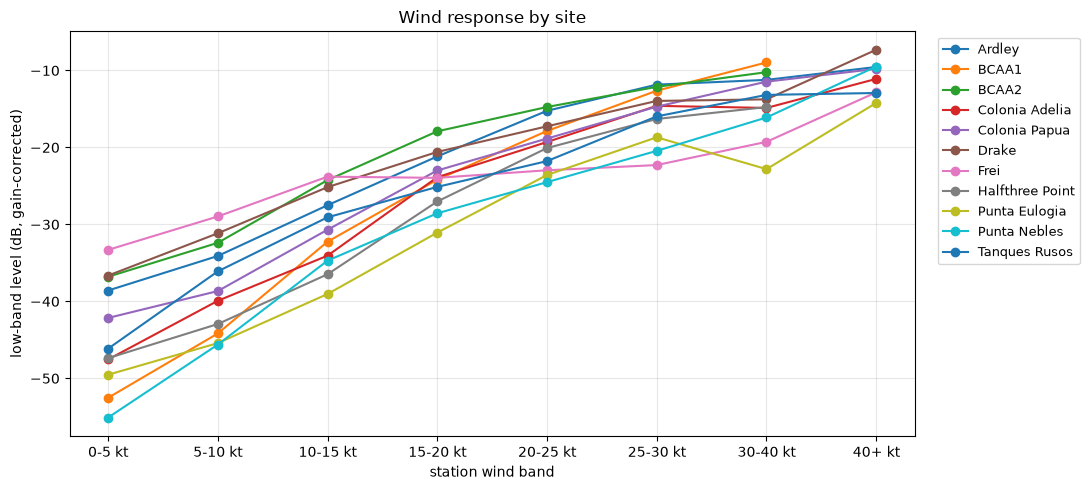

wind_band,0-5 kt,5-10 kt,10-15 kt,15-20 kt,20-25 kt,25-30 kt,30-40 kt,40+ kt
site,,,,,,,,
Ardley,-38.6,-34.1,-27.5,-21.2,-15.2,-11.8,-11.2,-9.5
BCAA1,-52.5,-44.2,-32.2,-24.2,-17.9,-12.6,-9.0,NaN
BCAA2,-36.8,-32.4,-24.2,-17.9,-14.7,-12.1,-10.2,NaN
Colonia Adelia,-47.5,-39.9,-34.1,-23.9,-19.3,-14.6,-14.9,-11.1
Colonia Papua,-42.2,-38.7,-30.7,-23.0,-18.8,-14.7,-11.5,-9.8
Drake,-36.7,-31.2,-25.2,-20.6,-17.3,-14.0,-13.8,-7.3
Frei,-33.3,-29.0,-23.8,-24.0,-23.0,-22.3,-19.3,-12.8
Halfthree Point,-47.4,-42.9,-36.5,-27.0,-20.1,-16.3,-14.8,NaN
Punta Eulogia,-49.5,-45.4,-39.0,-31.1,-23.6,-18.7,-22.8,-14.2


In [9]:
response = wind_response(air, metric="lf_level_db_gc", by=("site",), min_count=15)

fig, ax = plt.subplots(figsize=(11, 5))
for site, group in response.groupby("site", observed=True):
    group = group.sort_values("wind_band")
    ax.plot(group["wind_band"].astype(str), group["mean"], marker="o", label=site)
ax.set(xlabel="station wind band", ylabel="low-band level (dB, gain-corrected)",
       title="Wind response by site")
ax.legend(bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=9)
plt.tight_layout()
plt.show()

response.pivot_table(index="site", columns="wind_band", values="mean", observed=True).round(1)

### Which direction hurts

Wind direction matters as much as speed once a site is sheltered on one side.
This is the practical output for next season's deployment: the sector a site is
loudest in is the one it needs shelter from.

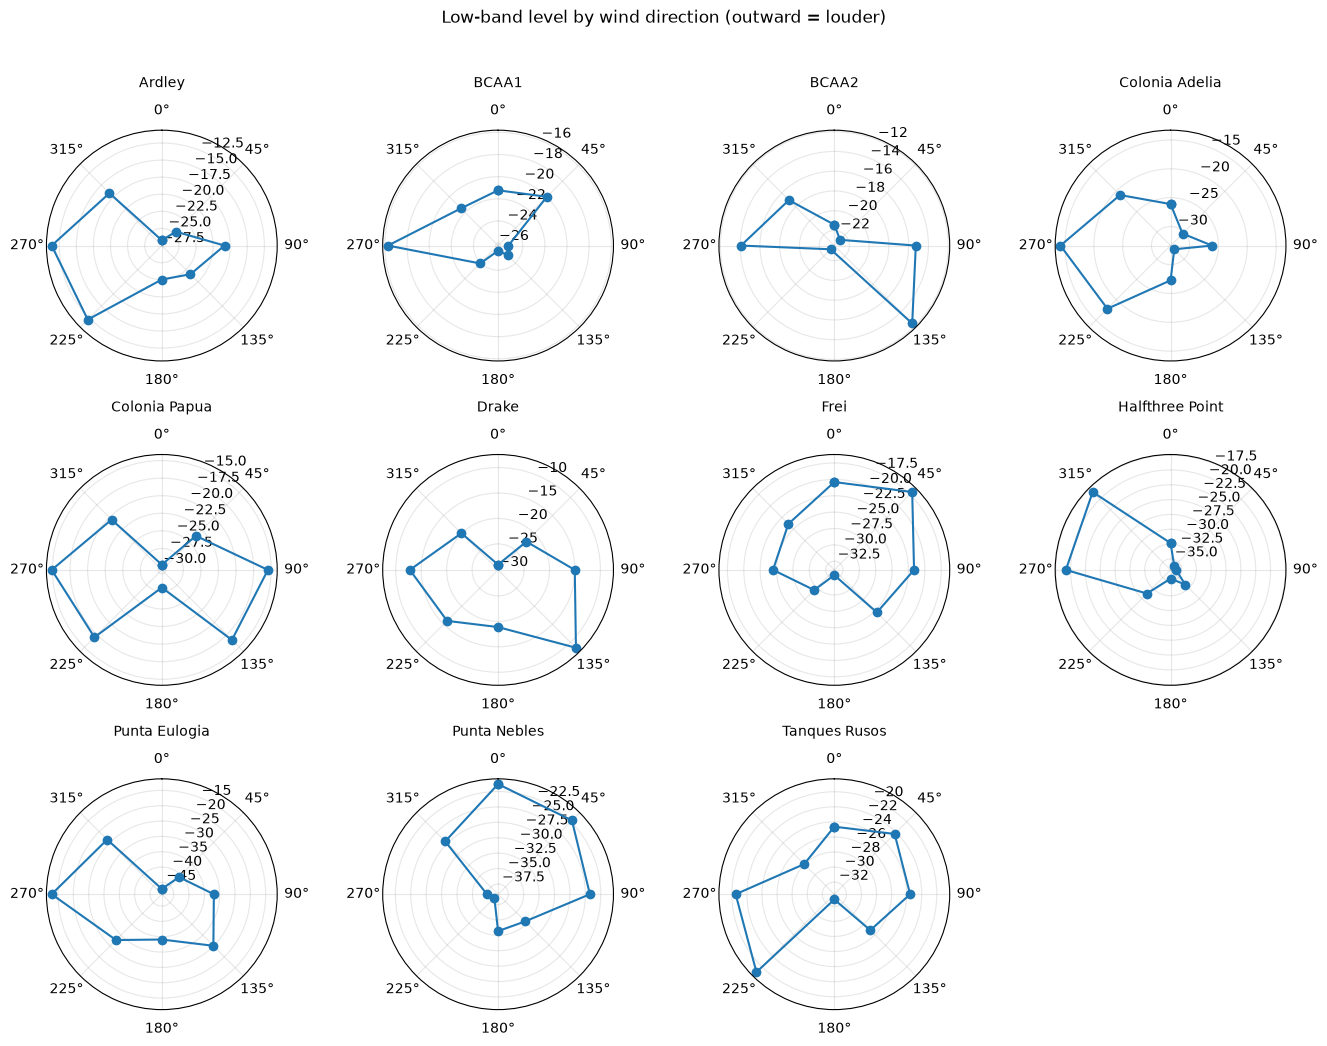

In [10]:
directions = direction_response(air, metric="lf_level_db_gc", by=("site",),
                                sectors=8, min_count=10)
sites = directions["site"].unique()
n_cols = min(4, len(sites))
n_rows = int(np.ceil(len(sites) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(3.4 * n_cols, 3.4 * n_rows),
                         subplot_kw={"projection": "polar"})
for ax, site in zip(np.atleast_1d(axes).ravel(), sites):
    group = directions[directions["site"] == site].sort_values("sector_deg")
    theta = np.deg2rad(group["sector_deg"].to_numpy())
    values = group["mean"].to_numpy()
    ax.plot(np.append(theta, theta[:1]), np.append(values, values[:1]), marker="o")
    ax.set_theta_zero_location("N")
    ax.set_theta_direction(-1)
    ax.set_title(site, fontsize=10, pad=12)
for ax in np.atleast_1d(axes).ravel()[len(sites):]:
    ax.set_visible(False)
fig.suptitle("Low-band level by wind direction (outward = louder)", y=1.02)
plt.tight_layout()
plt.show()

## 6. Are we getting better?
The scale break in section 2 forces this question to be asked twice, on
different evidence.
**The comparison that holds.** 2023-24 and 2024-25 share a wind scale *and*
share two sites — Colonia Papua and Colonia Adelia. Absolute wind bands are
valid across them, so this is a like-for-like answer.
**The comparison that spans all three seasons.** 2022-23 cannot be put on the
same wind axis, so bands are assigned by rank *within* each season instead.
That trades one assumption for another: rank-matching assumes the true wind
distribution was similar across seasons, so if 2022-23 really was calmer, that
difference is erased along with the instrument change. Read it as a sensitivity
check, not as the answer.
In both, the **raw** column is what a naive year-over-year average reports and
the **standardized** column re-weights onto one shared wind distribution. Where
they disagree, the difference is the weather.

In [11]:
post_break = air[air["season"].isin(["2023-24", "2024-25"])]
shared_sites = sorted(
    set(post_break[post_break["season"] == "2023-24"]["site"])
    & set(post_break[post_break["season"] == "2024-25"]["site"])
)
print("sites in both post-break seasons:", shared_sites)
comparable = post_break[post_break["site"].isin(shared_sites)]
weights_post = wind_weights(comparable)
holds = standardize_by_wind(comparable, metric="lf_level_db_gc",
                            by=("site", "season"), weights=weights_post, min_count=10)
holds["weather_effect"] = (holds["raw_mean"] - holds["standardized"]).round(2)
display(holds.round(2))
pivot = holds.pivot(index="site", columns="season", values="standardized")
change = (pivot["2024-25"] - pivot["2023-24"]).rename("change (dB)")
print("\nNegative means quieter at matched wind, i.e. better deployed:")
display(change.round(2).to_frame())

sites in both post-break seasons: ['Colonia Adelia', 'Colonia Papua']


,site,season,n,raw_mean,standardized,coverage,weather_effect
0,Colonia Adelia,2023-24,1227,-17.11,-17.05,1.00,-0.06
1,Colonia Adelia,2024-25,1263,-31.10,-31.12,1.00,0.02
2,Colonia Papua,2023-24,1223,-24.11,-24.03,1.00,-0.08
3,Colonia Papua,2024-25,1257,-21.35,-21.59,0.99,0.24



Negative means quieter at matched wind, i.e. better deployed:


,change (dB)
site,
Colonia Adelia,-14.08
Colonia Papua,2.45


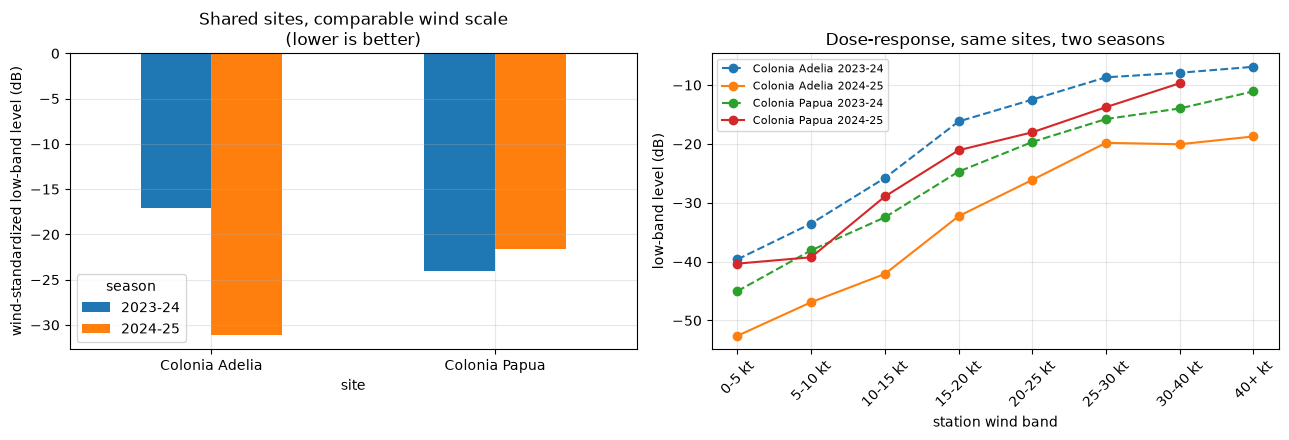

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
pivot.plot(kind="bar", ax=axes[0], rot=0)
axes[0].set(ylabel="wind-standardized low-band level (dB)",
            title="Shared sites, comparable wind scale\n(lower is better)")
axes[0].legend(title="season")
for site in shared_sites:
    curve = wind_response(comparable[comparable["site"] == site],
                          metric="lf_level_db_gc", by=("season",), min_count=10)
    for season, group in curve.groupby("season", observed=True):
        group = group.sort_values("wind_band")
        axes[1].plot(group["wind_band"].astype(str), group["mean"],
                     marker="o", ls="-" if season == "2024-25" else "--",
                     label=f"{site} {season}")
axes[1].set(xlabel="station wind band", ylabel="low-band level (dB)",
            title="Dose-response, same sites, two seasons")
axes[1].tick_params(axis="x", rotation=45)
axes[1].legend(fontsize=8)
plt.tight_layout()
plt.show()

### All three seasons, rank-matched
Bands are now each season's own quartiles of wind, which sidesteps the units.
The caveat above applies in full.

,season,n,raw_mean,standardized,coverage,weather_effect
0,2022-23,4546,-29.31,-29.48,1.0,0.17
1,2023-24,13967,-24.31,-24.40,1.0,0.09
2,2024-25,2529,-26.23,-26.34,1.0,0.12


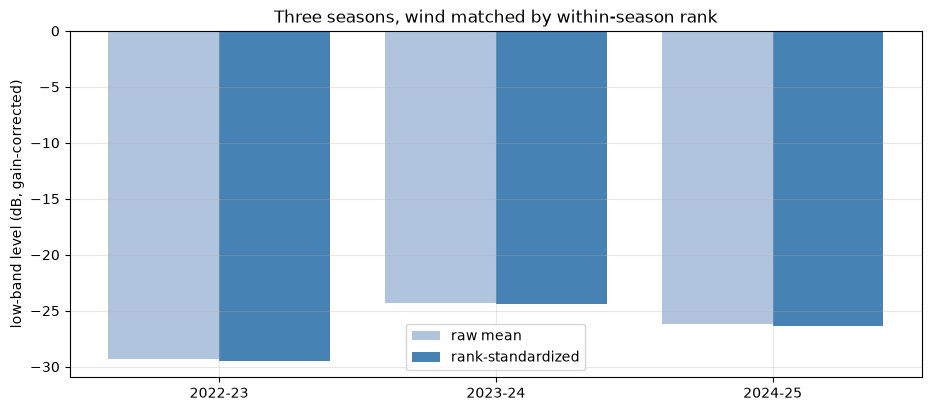

Site composition changes between seasons, so part of any trend here is
which places were instrumented that year:


site,Ardley,BCAA1,BCAA2,Colonia Adelia,Colonia Papua,Drake,Frei,Halfthree Point,Punta Eulogia,Punta Nebles,Tanques Rusos
season,,,,,,,,,,,
2022-23,0,0,0,0,0,0,2114,0,0,2230,2114
2023-24,1218,1281,1220,1229,1225,1382,1202,1377,1283,1244,1324
2024-25,0,0,0,1272,1272,0,0,0,0,0,0


In [13]:
ranked = add_wind_percentile_bands(air, by=("season",))
weights_rank = wind_weights(ranked, band_column="wind_pct_band")
three = standardize_by_wind(ranked, metric="lf_level_db_gc", by=("season",),
                            band_column="wind_pct_band", weights=weights_rank,
                            min_count=15)
three["weather_effect"] = (three["raw_mean"] - three["standardized"]).round(2)
display(three.round(2))
fig, ax = plt.subplots()
x = np.arange(len(three))
ax.bar(x - 0.2, three["raw_mean"], 0.4, label="raw mean", color="lightsteelblue")
ax.bar(x + 0.2, three["standardized"], 0.4, label="rank-standardized", color="steelblue")
ax.set_xticks(x, three["season"])
ax.set(ylabel="low-band level (dB, gain-corrected)",
       title="Three seasons, wind matched by within-season rank")
ax.legend()
plt.show()
print("Site composition changes between seasons, so part of any trend here is\n"
      "which places were instrumented that year:")
display(air.pivot_table(index="season", columns="site", values="path",
                        aggfunc="count", observed=True).fillna(0).astype(int))

### The 2022-23 to 2023-24 link
The other overlapping pair — Frei, Punta Nebles and Tanques Rusos were recorded
in both. This pair *does* straddle the scale break, so it is shown on rank
bands only.

In [14]:
early = air[air["season"].isin(["2022-23", "2023-24"])]
early_shared = sorted(
    set(early[early["season"] == "2022-23"]["site"])
    & set(early[early["season"] == "2023-24"]["site"])
)
print("sites in both early seasons:", early_shared)
early_ranked = add_wind_percentile_bands(
    early[early["site"].isin(early_shared)], by=("season", "site")
)
link = standardize_by_wind(early_ranked, metric="lf_level_db_gc",
                           by=("site", "season"), band_column="wind_pct_band",
                           weights=wind_weights(early_ranked, band_column="wind_pct_band"),
                           min_count=10)
display(link.round(2))
early_pivot = link.pivot(index="site", columns="season", values="standardized")
print("\nChange into 2023-24 (negative = quieter at matched rank):")
display((early_pivot["2023-24"] - early_pivot["2022-23"]).rename("change (dB)").round(2).to_frame())

sites in both early seasons: ['Frei', 'Punta Nebles', 'Tanques Rusos']


,site,season,n,raw_mean,standardized,coverage
0,Frei,2022-23,1561,-26.73,-23.59,1.0
1,Frei,2023-24,1199,-26.60,-26.76,1.0
2,Punta Nebles,2022-23,1424,-33.88,-37.08,1.0
3,Punta Nebles,2023-24,1242,-29.39,-29.72,1.0
4,Tanques Rusos,2022-23,1561,-27.07,-28.73,1.0
5,Tanques Rusos,2023-24,1322,-27.37,-27.80,1.0



Change into 2023-24 (negative = quieter at matched rank):


,change (dB)
site,
Frei,-3.16
Punta Nebles,7.37
Tanques Rusos,0.94


## 7. Deployment quality, which is a different question

Saturation is a gain choice. Silence and unreadable files are hardware, cards
and batteries. None of these are about wind, and all are things experience
should improve.

**Reliability has to be measured on the inventory, not on the analysis.** The
analysis worklist only contains files that could be opened, so an error rate
computed from it is 0 by construction. The honest denominator is every file the
recorder wrote.

,files,failed,failure_rate
season,,,
2022-23,7741,1252,0.1617
2023-24,120388,2649,0.0220
2024-25,31585,0,0.0000


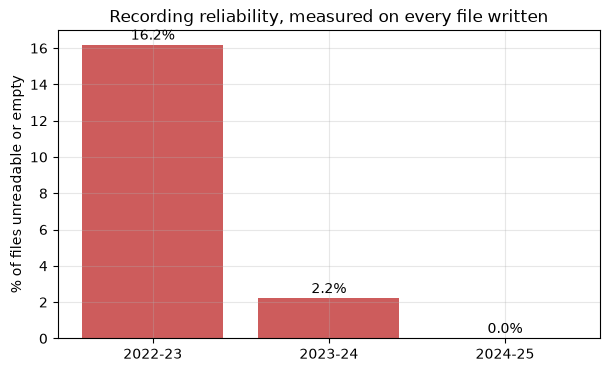

Where the failures were:


failed files
season  site                       
2022-23 Punta Nebles           1252
2023-24 Ardley                  464
        BCAA1                   271
        BCAA2                     1
        Frei                    378
        Punta Eulogia          1165
        Punta Nebles            100
        Tanques Rusos           270

In [15]:
inventory_all = pd.read_parquet(INVENTORY)
inventory_all["header_error"] = inventory_all["header_error"].fillna("")

# A file counts as failed if its header cannot be read or it holds no audio.
inventory_all["failed"] = (
    inventory_all["header_error"].ne("")
    | inventory_all["duration_s"].fillna(-1).eq(0)
)

reliability = (
    inventory_all.groupby("season", observed=True)["failed"]
    .agg(files="size", failed="sum", failure_rate="mean")
    .round(4)
)
display(reliability)

fig, ax = plt.subplots(figsize=(7, 4))
ax.bar(reliability.index, reliability["failure_rate"] * 100, color="indianred")
for x, v in zip(reliability.index, reliability["failure_rate"] * 100):
    ax.text(x, v + 0.3, f"{v:.1f}%", ha="center")
ax.set(ylabel="% of files unreadable or empty",
       title="Recording reliability, measured on every file written")
plt.show()

print("Where the failures were:")
failed = inventory_all[inventory_all["failed"]]
display(failed.groupby(["season", "site"], observed=True).size().rename("failed files").to_frame())

### Saturation, and what it costs the wind measurement

Saturation is high throughout — roughly a third to a half of all recordings
clip somewhere. That matters beyond the files themselves: a clipped recording
cannot get louder, so the low-band level saturates too. The dose-response
curves in section 5 are therefore **compressed at the top end**, and the true
difference between a gale and a strong gale is larger than they show.

,season,n,saturated_rate,silent_rate,clicky_rate,windy_rate,error_rate
0,2022-23,6458,0.306,0.017,0.159,0.378,0.0
1,2023-24,13985,0.448,0.000,0.294,0.514,0.0
2,2024-25,2544,0.381,0.006,0.284,0.537,0.0


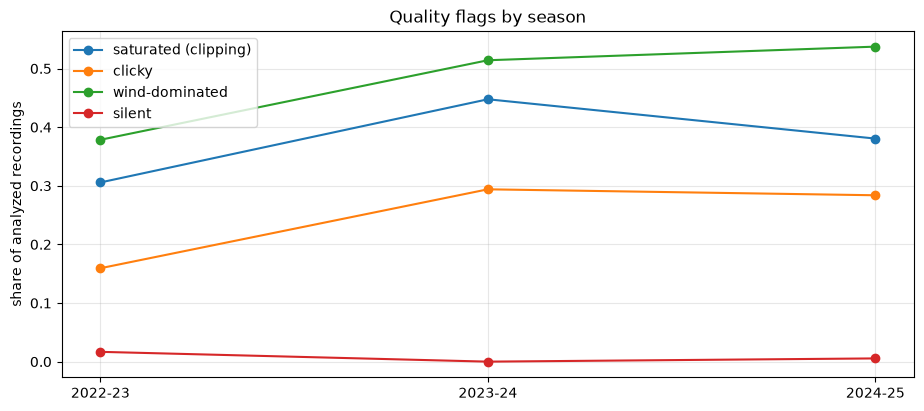

Clipping rises with wind, which is exactly where the level matters most:


,n,saturated_rate
wind_band,,
0-5 kt,796,0.006
5-10 kt,2998,0.053
10-15 kt,4905,0.215
15-20 kt,4586,0.396
20-25 kt,3808,0.610
25-30 kt,2334,0.769
30-40 kt,1402,0.835
40+ kt,213,0.920


,season,site,n,saturated_rate,silent_rate,clicky_rate,windy_rate,error_rate
0,2022-23,Frei,2114,0.256,0.000,0.107,0.442,0.0
1,2022-23,Punta Nebles,2230,0.263,0.046,0.181,0.269,0.0
2,2022-23,Tanques Rusos,2114,0.400,0.003,0.189,0.430,0.0
3,2023-24,Ardley,1218,0.589,0.000,0.444,0.639,0.0
4,2023-24,BCAA1,1281,0.441,0.000,0.271,0.564,0.0
5,2023-24,BCAA2,1220,0.501,0.000,0.234,0.662,0.0
6,2023-24,Colonia Adelia,1229,0.748,0.000,0.576,0.711,0.0
7,2023-24,Colonia Papua,1225,0.350,0.000,0.291,0.551,0.0
8,2023-24,Drake,1382,0.529,0.000,0.306,0.549,0.0
9,2023-24,Frei,1202,0.175,0.000,0.126,0.297,0.0


In [16]:
quality = deployment_quality(air, by=("season",))
display(quality.round(3))

fig, ax = plt.subplots()
for column, label in [("saturated_rate", "saturated (clipping)"),
                      ("clicky_rate", "clicky"),
                      ("windy_rate", "wind-dominated"),
                      ("silent_rate", "silent")]:
    if column in quality:
        ax.plot(quality["season"], quality[column], marker="o", label=label)
ax.set(ylabel="share of analyzed recordings", title="Quality flags by season")
ax.legend()
plt.show()

# How much of the level range is lost to clipping, per wind band.
clip_by_wind = (
    air.dropna(subset=["wind_band"])
    .groupby("wind_band", observed=True)
    .agg(n=("is_saturated", "size"), saturated_rate=("is_saturated", "mean"))
)
print("Clipping rises with wind, which is exactly where the level matters most:")
display(clip_by_wind[clip_by_wind["n"] >= 20].round(3))

display(deployment_quality(air, by=("season", "site")).round(3))

## 8. What this does and does not establish

**Supported by the data above**
- The acoustic signal tracks the station anemometer: r ≈ 0.57 for level-based
  metrics, against a station kilometres from most sites. The clock alignment is
  confirmed empirically rather than assumed.
- Which sites are exposed and from which direction — directly actionable.
- Season-over-season change at matched wind for 2023-24 vs 2024-25, on shared
  sites and a shared wind scale. This is the one clean "did we learn" result.
- Recording reliability, measured on every file written.

**Not supported, and worth stating plainly**
- The station's wind column changes scale before the 2023-24 season (section 2).
  Anything spanning that boundary rests on rank-matching, which assumes the true
  wind distribution was similar across seasons. If 2022-23 was genuinely calmer,
  rank-matching erases that along with the instrument change.
- The weather comes from *one station*. For a site kilometres away it is an
  index of the day's conditions, not a measurement at the microphone. Site
  differences that look like shelter may partly be distance from the station.
- A third to a half of recordings clip. Clipped audio cannot get louder, so the
  high-wind end of every dose-response curve is compressed, and differences
  between strong and very strong wind are understated.
- Gain correction uses AudioMoth's *nominal* 6 dB steps, not a calibration.
  Differences of 1-2 dB between seasons should not be read as real.
- No airborne site spans all three seasons, so the three-season trend is a chain
  of overlapping pairs rather than one continuous series. The corpus-wide
  comparison also mixes a changing set of sites.
- Levels are dBFS, not sound pressure. They compare recordings to each other,
  not to an absolute acoustic scale.
- These are ~1,200-2,200 recordings per site-season, sampled evenly across each
  deployment, not the full 160k corpus.

**Worth confirming off the data**
- Whether the anemometer or its logging changed before the 2023-24 season. A
  station logbook would settle section 2 outright.
- What changed at Colonia Adelia between the two seasons — it is the largest
  single improvement in the corpus and worth knowing how it was achieved.